In [1]:
import os
os.chdir("..")

In [2]:
from src.data.cwru_load_data import cwru_read_mat, cwru_read_normal
import numpy as np
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal as sig
import pywt
from scipy.signal import hilbert
import pandas as pd
import scipy.stats as sps
from scipy.signal import resample_poly

In [3]:
de_data = cwru_read_mat(r"D:\Capstone\data\raw\CWRU\12k_Drive_End_Bearing_Fault_Data")
fe_data = cwru_read_mat(r"D:\Capstone\data\raw\CWRU\12k_Fan_End_Bearing_Fault_Data")
norm_data = cwru_read_normal(r"D:\Capstone\data\raw\CWRU\Normal")

In [4]:
de_time = de_data['OR']['007']['@6'][0]['X130_DE_time'].flatten()
fe_time = fe_data['OR']['007']['@6'][0]['X294_DE_time'].flatten()
norm_de_time = norm_data['100_Normal_3']['X100_DE_time'].flatten()
norm_fe_time = norm_data['100_Normal_3']['X100_FE_time'].flatten()

norm_de_time = resample_poly(norm_de_time, up=1, down=4)
norm_fe_time = resample_poly(norm_fe_time, up=1, down=4)

signal_list = [de_time, fe_time, norm_de_time, norm_fe_time]
label_list = ['Drive-end Fault', 'Fan-end Fault', 'Normal Drive-end', 'Normal Fan-end']

for signal, label in zip(signal_list, label_list):
    print(f"{label} signal length: {len(signal)}")

Drive-end Fault signal length: 121991
Fan-end Fault signal length: 121168
Normal Drive-end signal length: 121411
Normal Fan-end signal length: 121411


# General Statistics

In [5]:
stats_df = pd.DataFrame(columns=['Label', 'Mean', 'Std Dev', 'Min', 'Max', 'RMS', 'Peak2Peak', 'Kurtosis', 'Skewness'])

for signal, label in zip(signal_list, label_list):
    stats = [
        label,
        np.mean(signal),
        np.std(signal),
        np.min(signal),
        np.max(signal),
        np.sqrt(np.mean(signal**2)),
        np.ptp(signal),
        pd.Series(signal).kurtosis(),
        pd.Series(signal).skew()
    ]

    stats_df.loc[len(stats_df)] = stats

stats_df

,Label,Mean,Std Dev,Min,Max,RMS,Peak2Peak,Kurtosis,Skewness
0,Drive-end Fault,0.023171,0.669104,-3.408701,3.630425,0.669506,7.039126,4.649674,0.056947
1,Fan-end Fault,0.002329,0.154251,-0.996702,1.027240,0.154269,2.023942,3.467680,-0.017987
2,Normal Drive-end,0.012458,0.056568,-0.247227,0.274281,0.057924,0.521508,0.051995,0.029442
3,Normal Fan-end,0.031896,0.067259,-0.286643,0.347729,0.074439,0.634372,0.149046,-0.061397


# Raw Vibration Signal Over Time

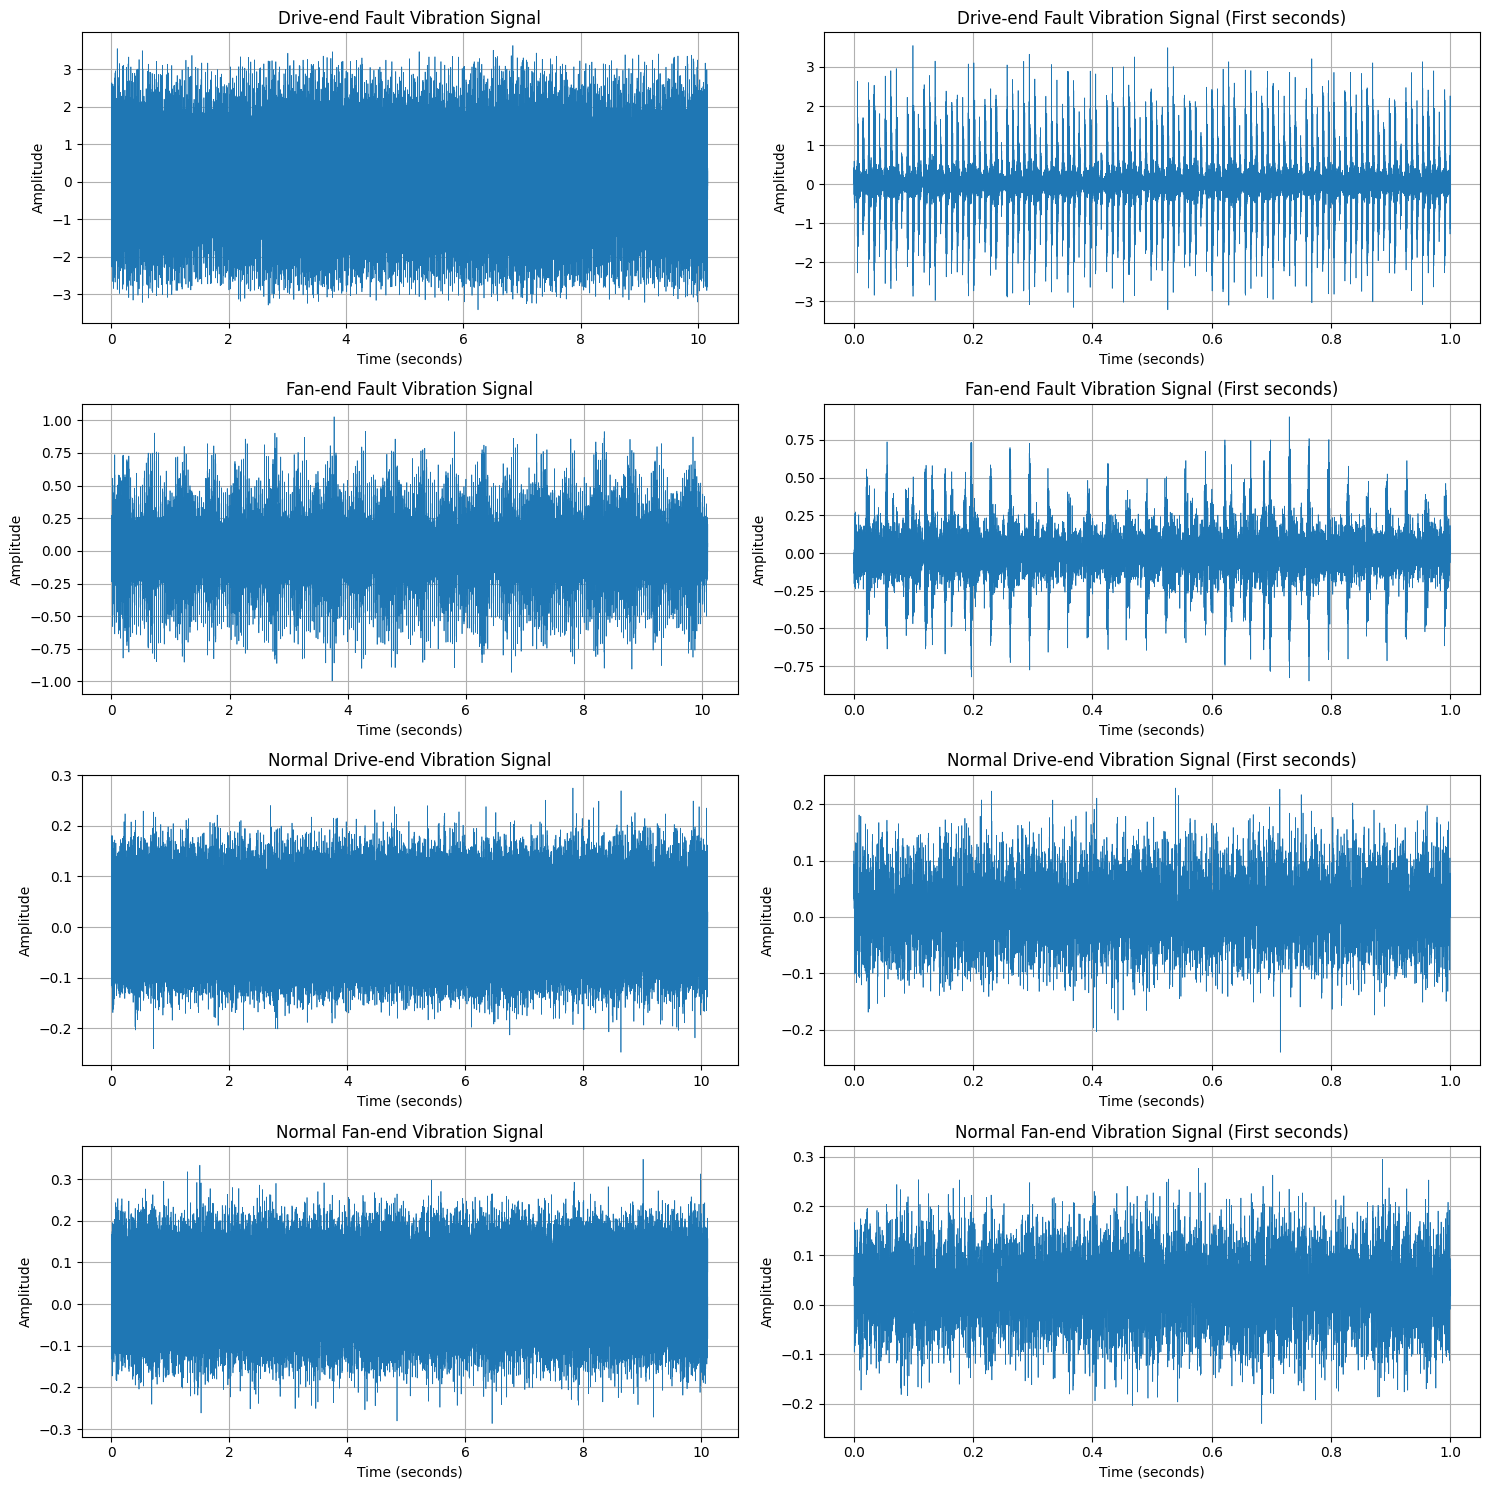

In [6]:
def raw_vibration_signal(fs, signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 2, figsize=(15, 15))
    for i in range(len(axes)):
        axes[i, 0].plot(np.arange(len(signal_list[i])) / fs,
                        signal_list[i], linewidth=0.5)
        axes[i, 0].set_xlabel('Time (seconds)')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].set_title(f"{label_list[i]} Vibration Signal")
        axes[i, 0].grid(True)

        axes[i, 1].plot((np.arange(len(signal_list[i])) / fs)[:int(1 * fs)],
                        signal_list[i][:int(1 * fs)], linewidth=0.5)
        axes[i, 1].set_xlabel('Time (seconds)')
        axes[i, 1].set_ylabel('Amplitude')
        axes[i, 1].set_title(f"{label_list[i]} Vibration Signal (First seconds)")
        axes[i, 1].grid(True)

    plt.tight_layout()  
    plt.plot()
        
raw_vibration_signal(12000, signal_list, label_list)

# Outer Race Fault Position Comparison

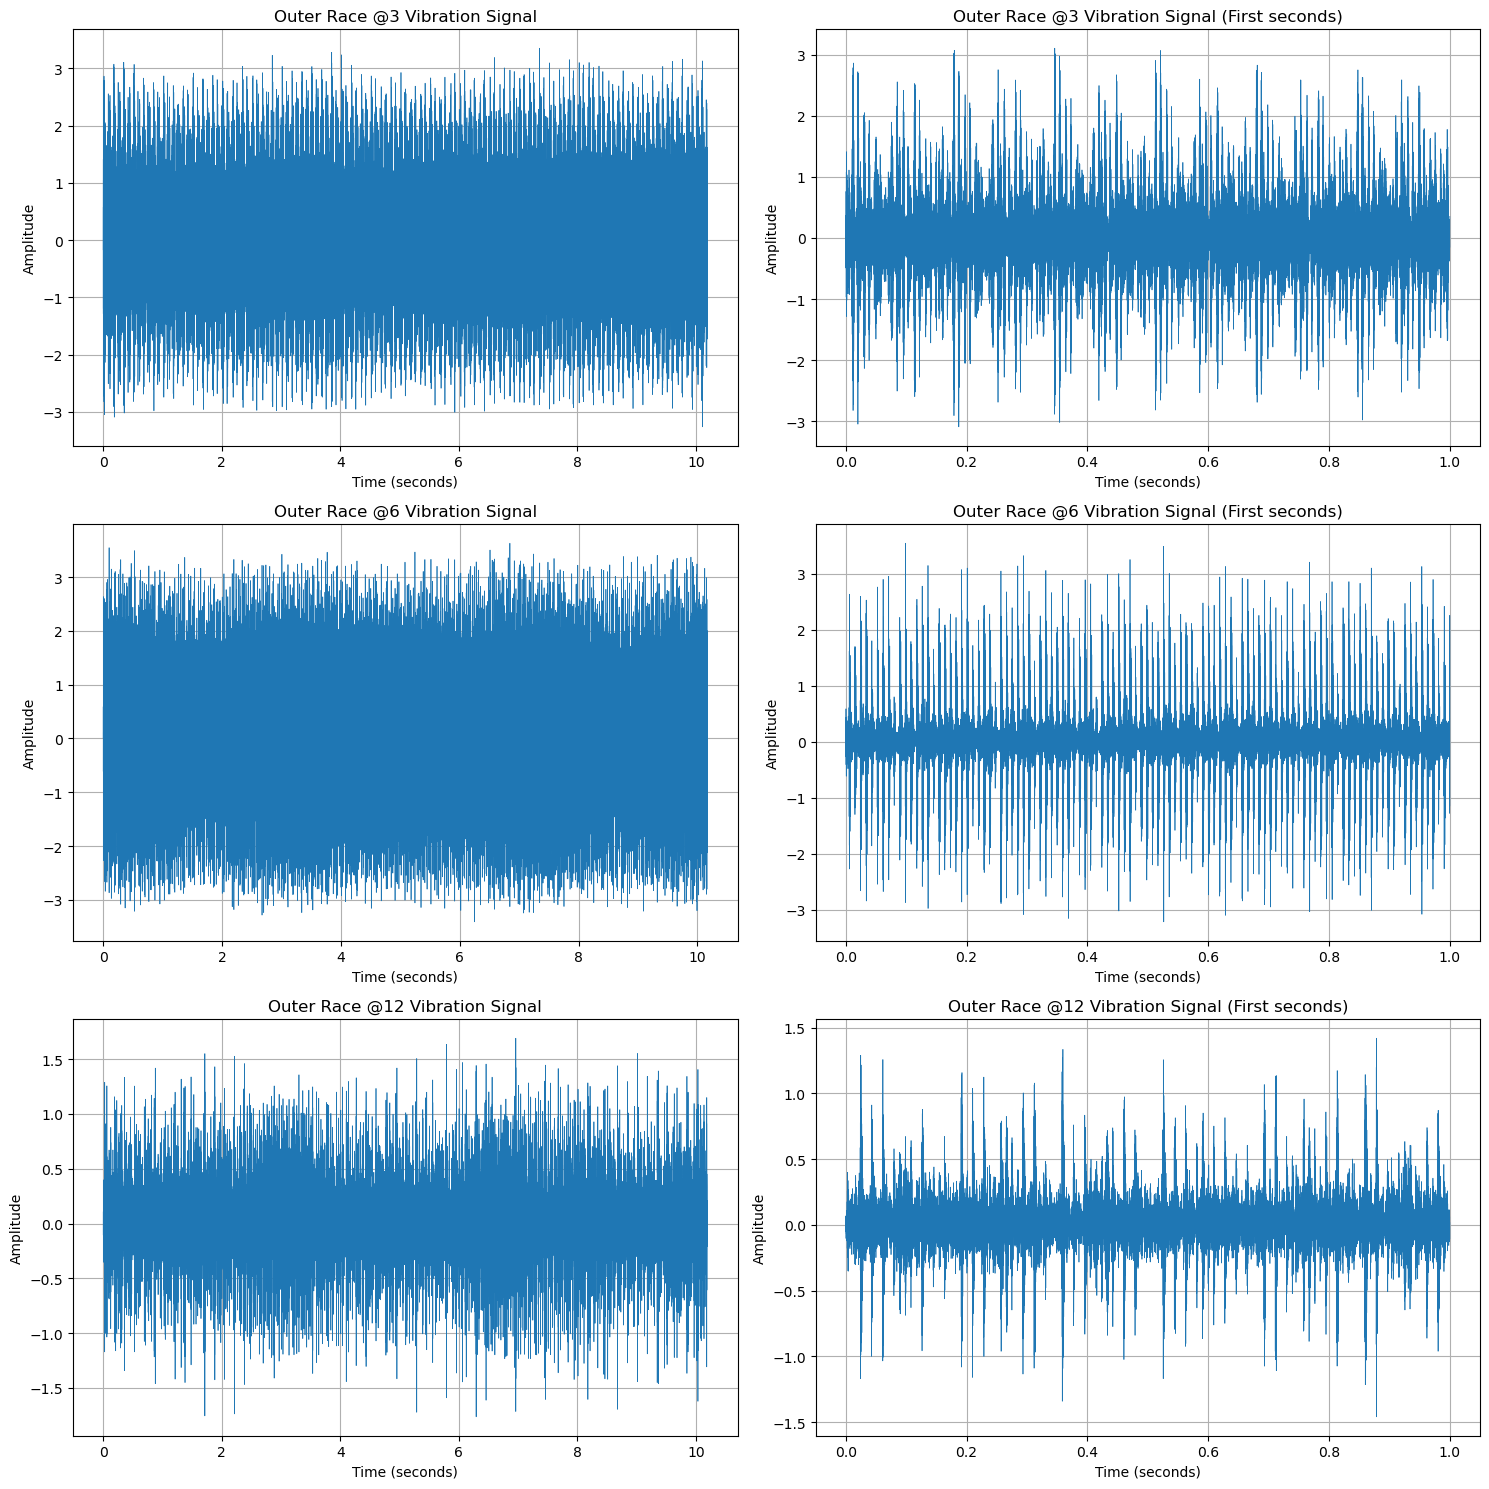

In [28]:
position_list = [
    de_data['OR']['007']['@3'][0]['X144_DE_time'].squeeze(),
    de_data['OR']['007']['@6'][0]['X130_DE_time'].squeeze(),
    de_data['OR']['007']['@12'][0]['X156_DE_time'].squeeze()
]

position_label = ["Outer Race @3", "Outer Race @6", "Outer Race @12"]
        
raw_vibration_signal(12000, position_list, position_label)

# Fault Severity Comparison

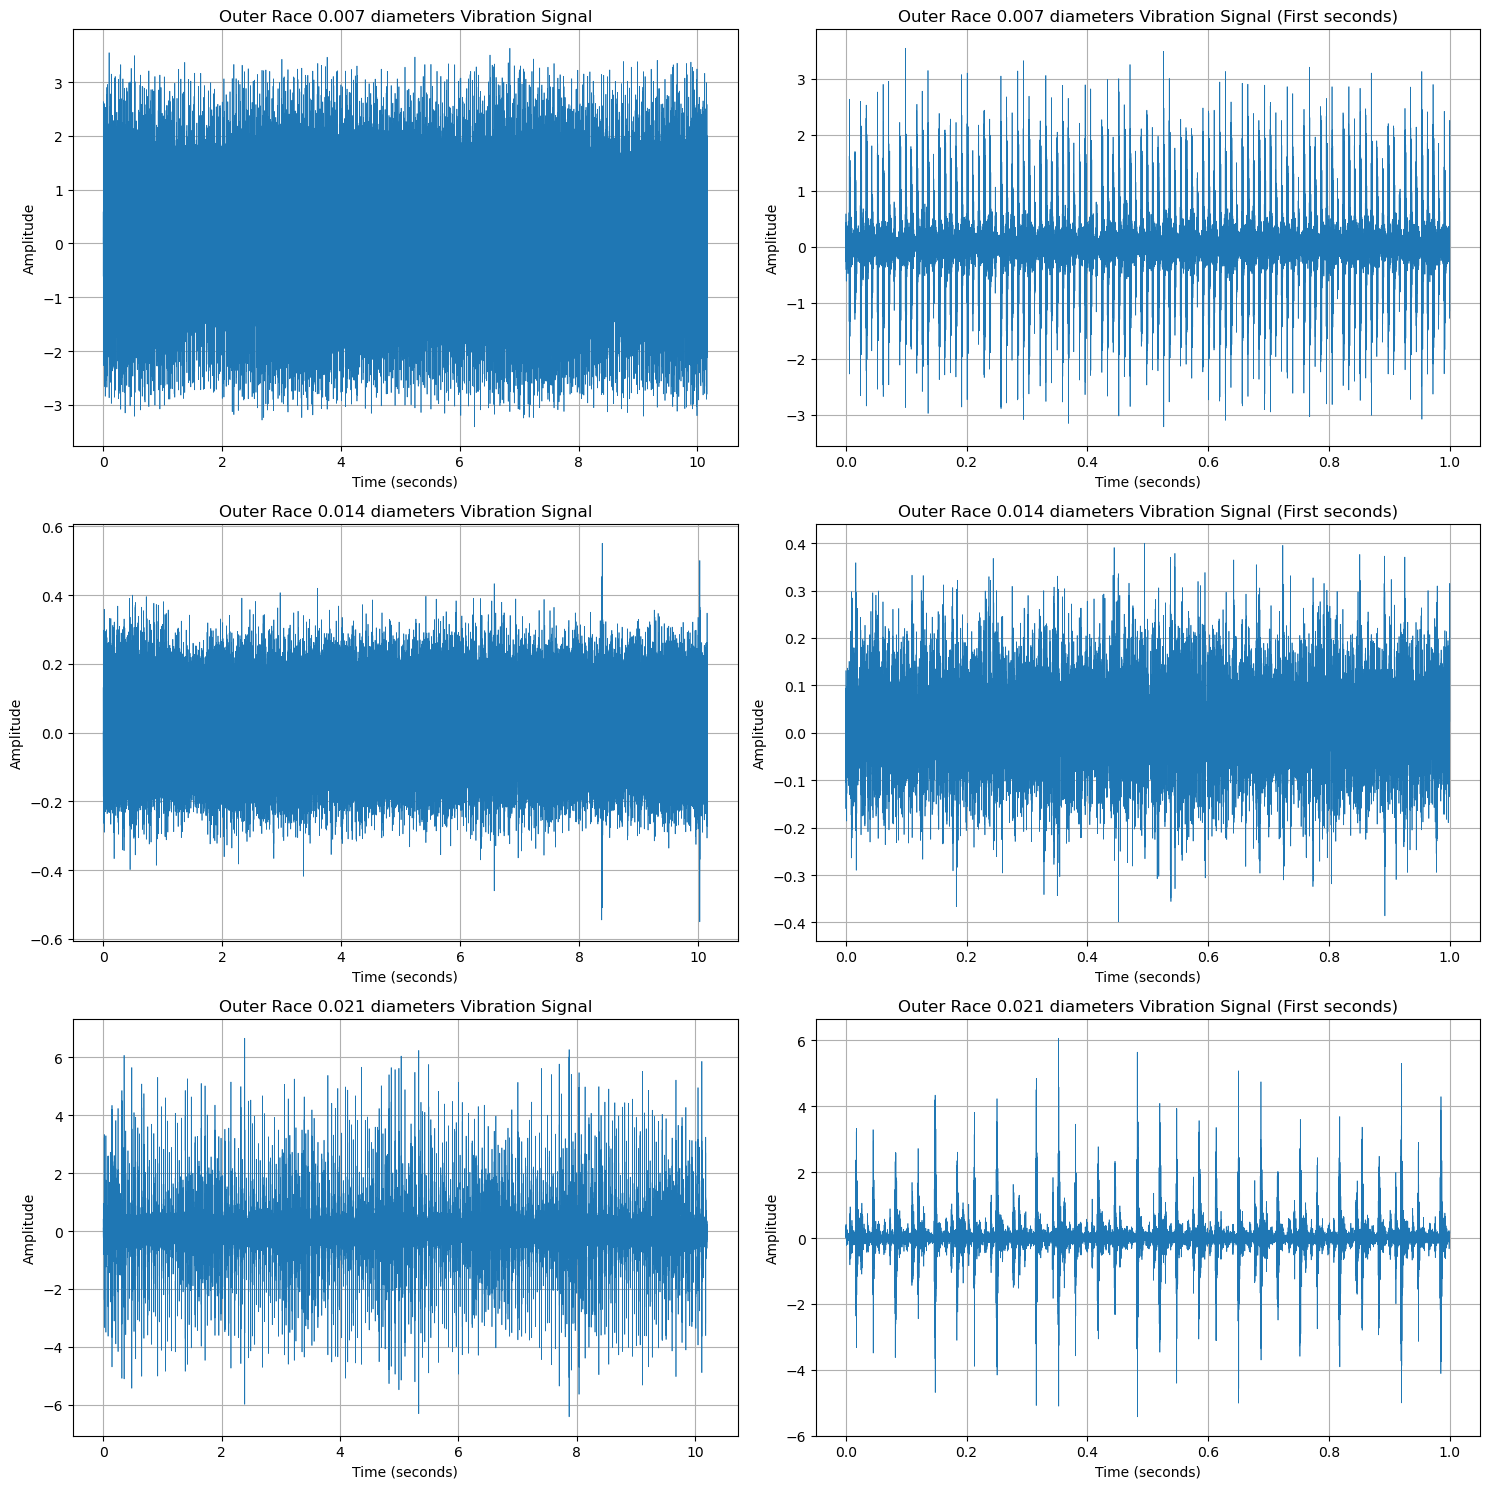

In [40]:
severity_list = [
    de_data['OR']['007']['@6'][0]['X130_DE_time'],
    de_data['OR']['014']['default'][0]['X197_DE_time'],
    de_data['OR']['021']['@6'][0]['X234_DE_time'],
]

severity_label = ["Outer Race 0.007 diameters", "Outer Race 0.014 diameters", "Outer Race 0.021 diameters"]
        
raw_vibration_signal(12000, severity_list, severity_label)

# Frequency Domain Analysis

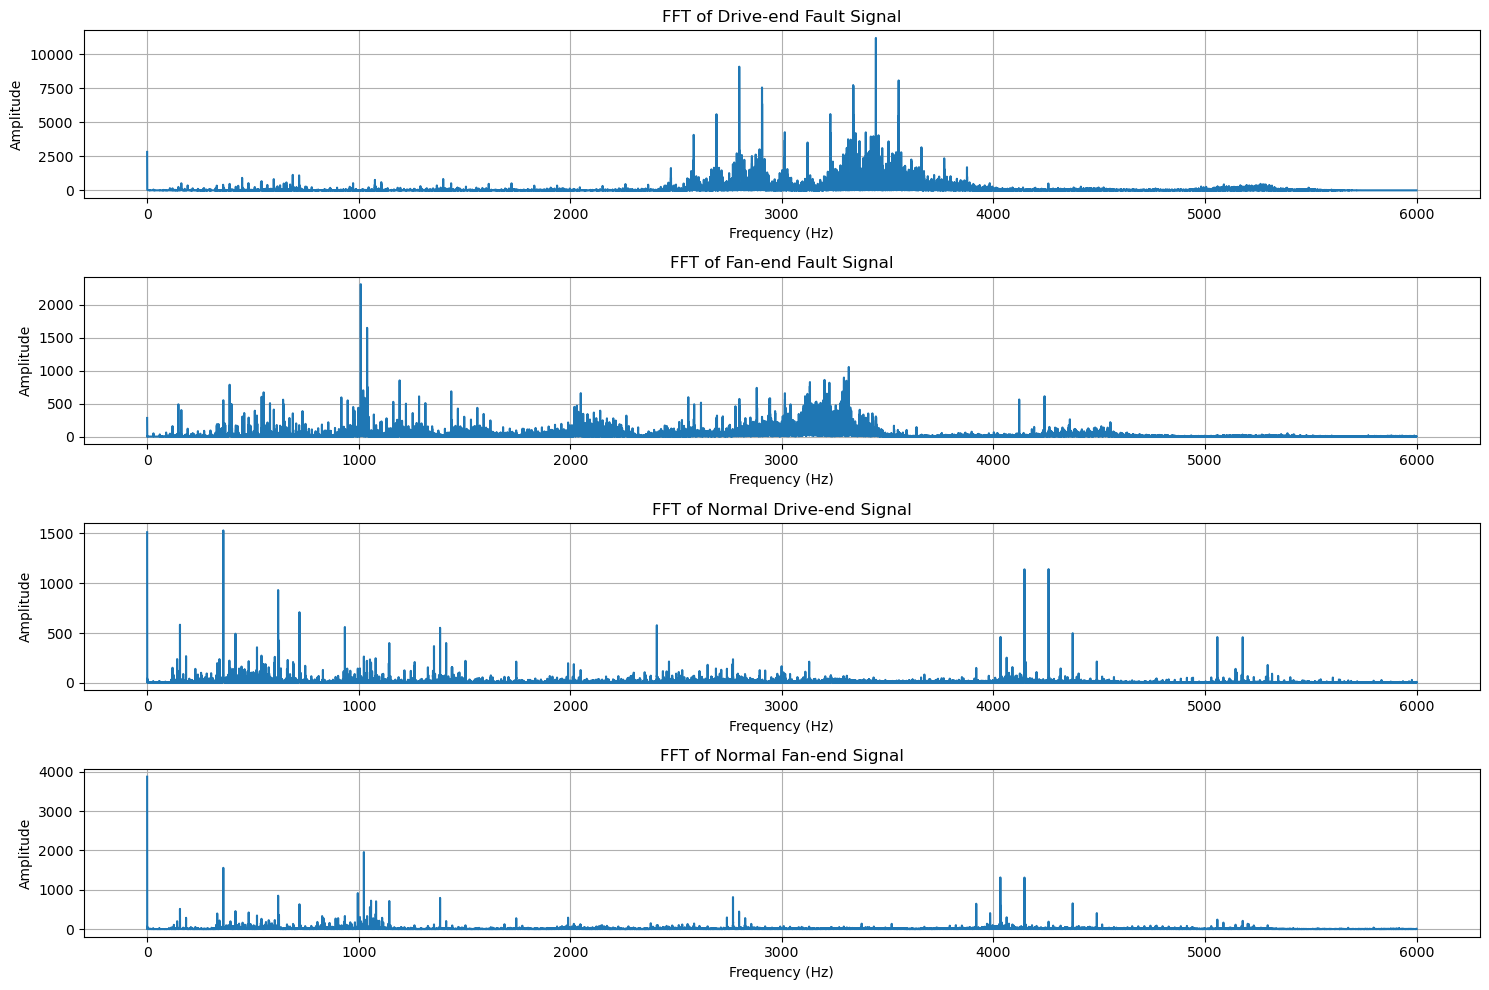

In [41]:
def fast_fourier_transform(fs, signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 10))
    for i in range(len(signal_list)):
        fft_vals = np.fft.fft(signal_list[i])
        fft_freq = np.fft.fftfreq(len(signal_list[i]), 1/fs)
        positive_freq = fft_freq[:len(fft_freq)//2]
        amplitude = np.abs(fft_vals[:len(fft_vals)//2])

        axes[i].plot(positive_freq, amplitude)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_title(f'FFT of {label_list[i]} Signal')
        axes[i].grid(True)

    plt.tight_layout()
    plt.plot()

fast_fourier_transform(12000, signal_list, label_list)

# Power Spectral Density

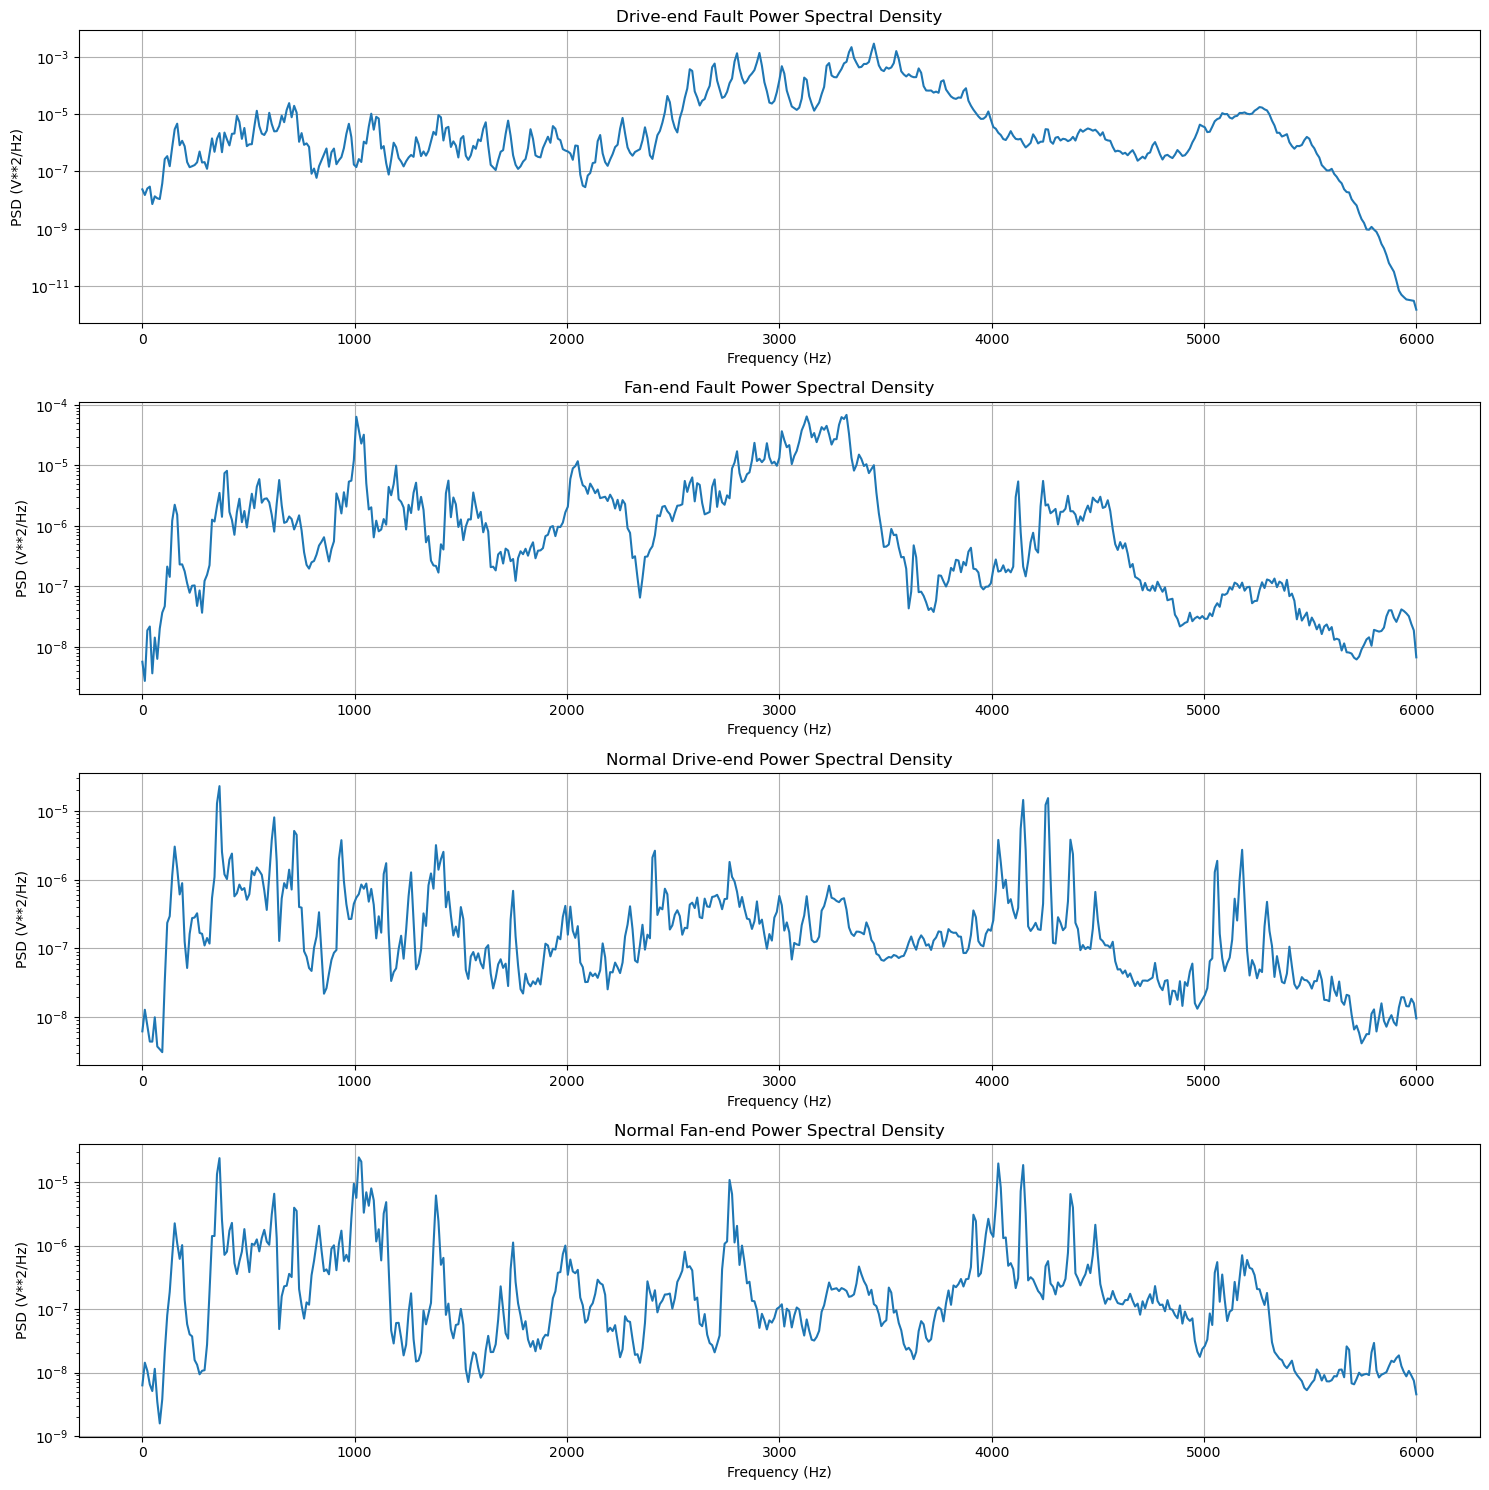

In [46]:
def power_sepctral_density(fs, nperseg, signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 15))
    for i in range(len(signal_list)):
        from scipy import signal
        f, psd = signal.welch(signal_list[i], fs, nperseg=nperseg)
        
        axes[i].semilogy(f, psd)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('PSD (V**2/Hz)')
        axes[i].set_title(f'{label_list[i]} Power Spectral Density')
        axes[i].grid(True)

    plt.tight_layout()
    plt.plot()

power_sepctral_density(12000, 1024, signal_list, label_list)

# Time-domain features

In [54]:
stats_df = pd.DataFrame(columns=['Label', 'Impluse Factor', 'Shape Factor'])

for signal, label in zip(signal_list, label_list):
    stats = [
        label,
        np.max(np.abs(signal)) / np.mean(np.abs(signal)),
        np.sqrt(np.mean(signal**2)) / np.mean(np.abs(signal))
    ]

    stats_df.loc[len(stats_df)] = stats

stats_df

,Label,Impluse Factor,Shape Factor
0,Drive-end Fault,8.947742,1.650100
1,Fan-end Fault,9.365815,1.406539
2,Normal Drive-end,5.954305,1.257451
3,Normal Fan-end,5.842779,1.250772


# Frequency-domain features

In [55]:
def frequency_domain_features(fs, signal_list, label_list):
    stats_df = pd.DataFrame(columns=['Label', 'Spectral Centroid', 'Spectral Variance', 'Peak Frequency', 'Max Amplitude'])
    for i in range(len(signal_list)):
        fft = np.fft.fft(signal_list[i])
        magnitude = np.abs(fft[:len(fft)//2])
        freq = np.fft.fftfreq(len(signal_list[i]), 1/fs)[:len(fft)//2]

        spectral_centroid = np.sum(freq * magnitude) / np.sum(magnitude)
        spectral_variance = np.sum(((freq - spectral_centroid)**2) * magnitude) / np.sum(magnitude)

        for signal, label in zip(signal_list, label_list):
            stats = [
                label,
                spectral_centroid,
                spectral_variance,
                freq[np.argmax(magnitude)],
                np.max(magnitude)
            ]

        stats_df.loc[len(stats_df)] = stats

    return stats_df

frequency_domain_features(48000, signal_list, label_list)

,Label,Spectral Centroid,Spectral Variance,Peak Frequency,Max Amplitude
0,Normal Fan-end,13088.126868,1.396550e+07,13778.196752,11207.761747
1,Normal Fan-end,11337.557167,2.151250e+07,4039.482372,2308.244672
2,Normal Fan-end,11123.736842,3.944654e+07,1440.264885,1530.467261
3,Normal Fan-end,11359.718345,4.280357e+07,0.000000,3872.584574


# Envelope analysis

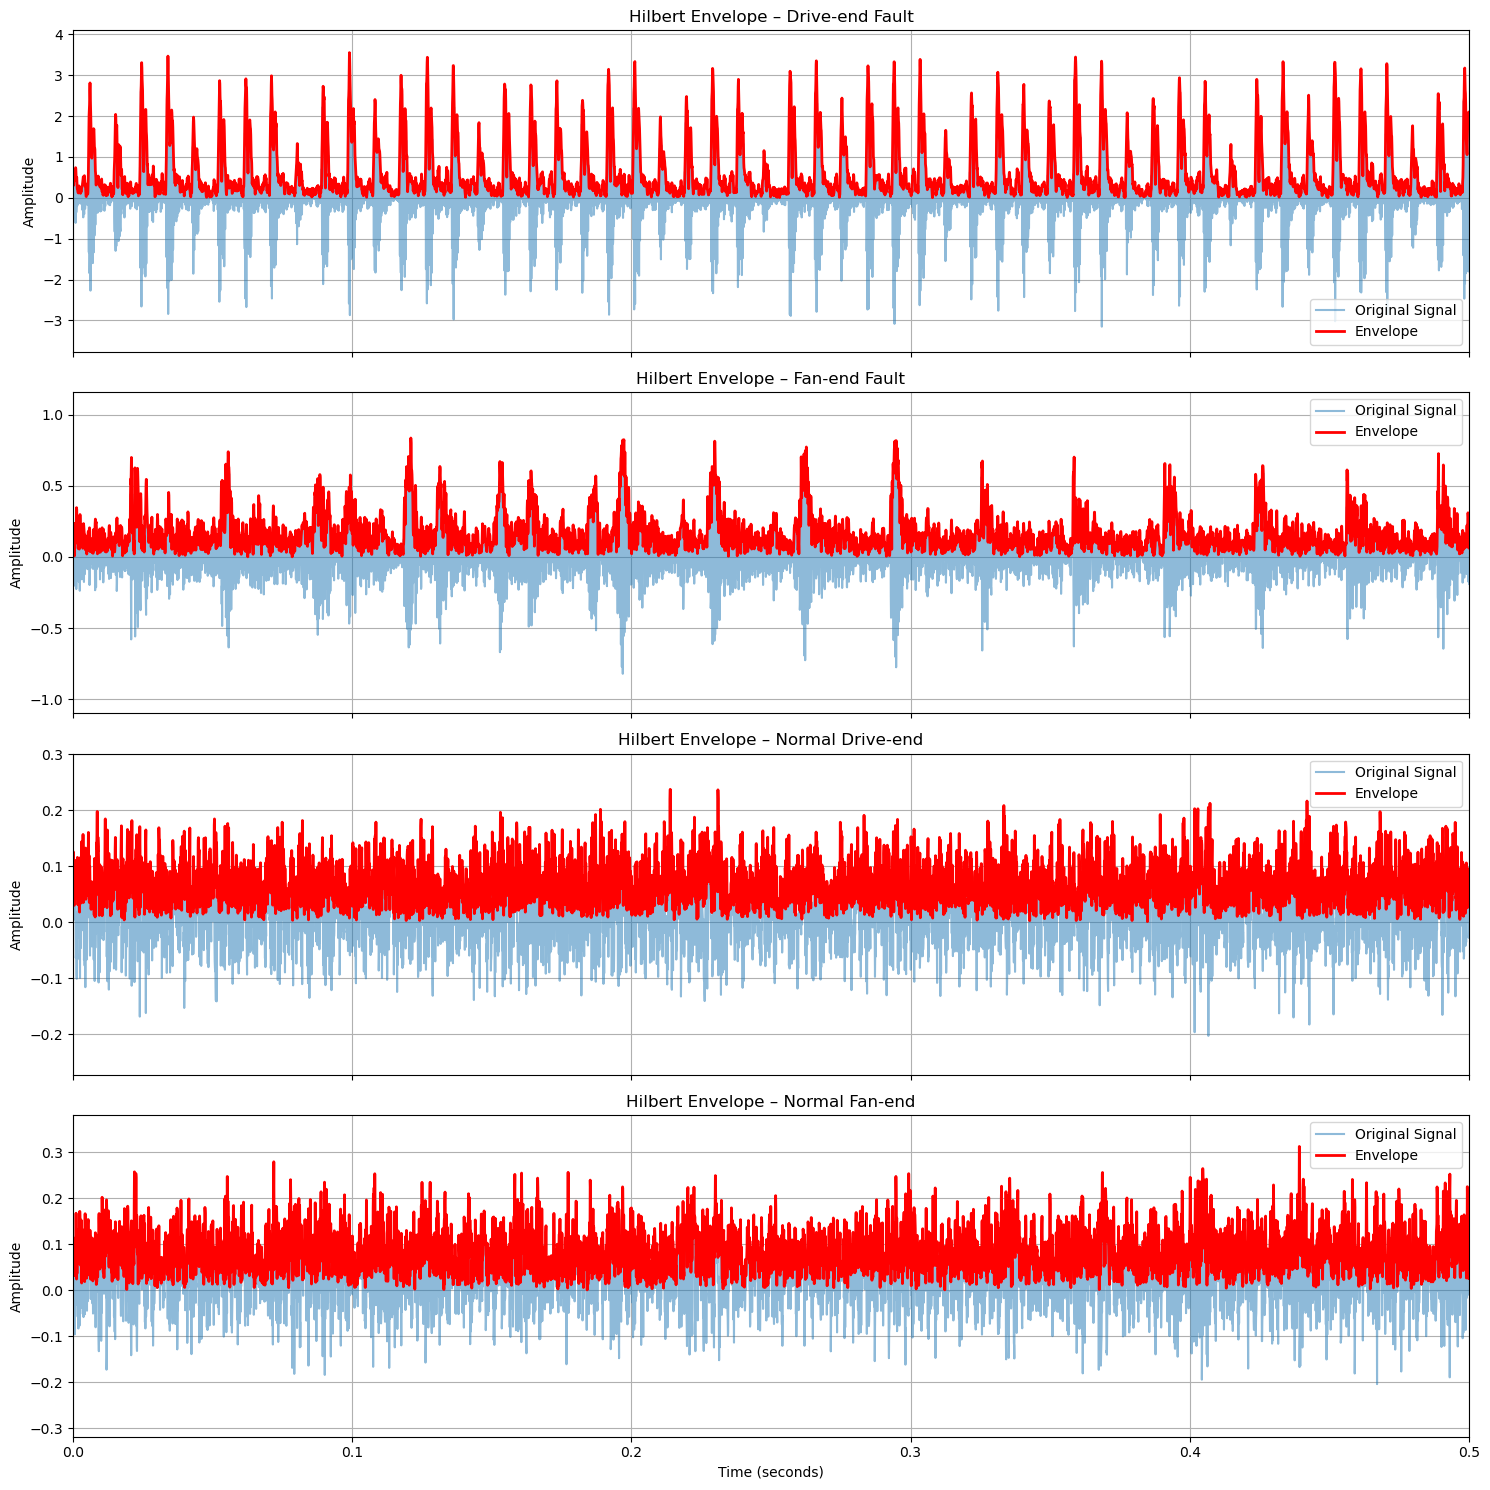

In [57]:
def envelope_analysis(fs, signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 15), sharex=True)

    for i in range(len(signal_list)):
        time = np.arange(len(signal_list[i])) / fs
        analytic_signal = hilbert(signal_list[i])
        amplitude_envelope = np.abs(analytic_signal)

        axes[i].plot(time, signal_list[i],
                     alpha=0.5, label='Original Signal')
        axes[i].plot(time, amplitude_envelope,
                     'r', linewidth=2, label='Envelope')

        axes[i].set_ylabel('Amplitude')
        axes[i].set_title(f'Hilbert Envelope – {label_list[i]}')
        axes[i].set_xlim(0, 0.5)
        axes[i].grid(True)
        axes[i].legend()

    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.show()

envelope_analysis(12000, signal_list, label_list)

# FFT of Envelope

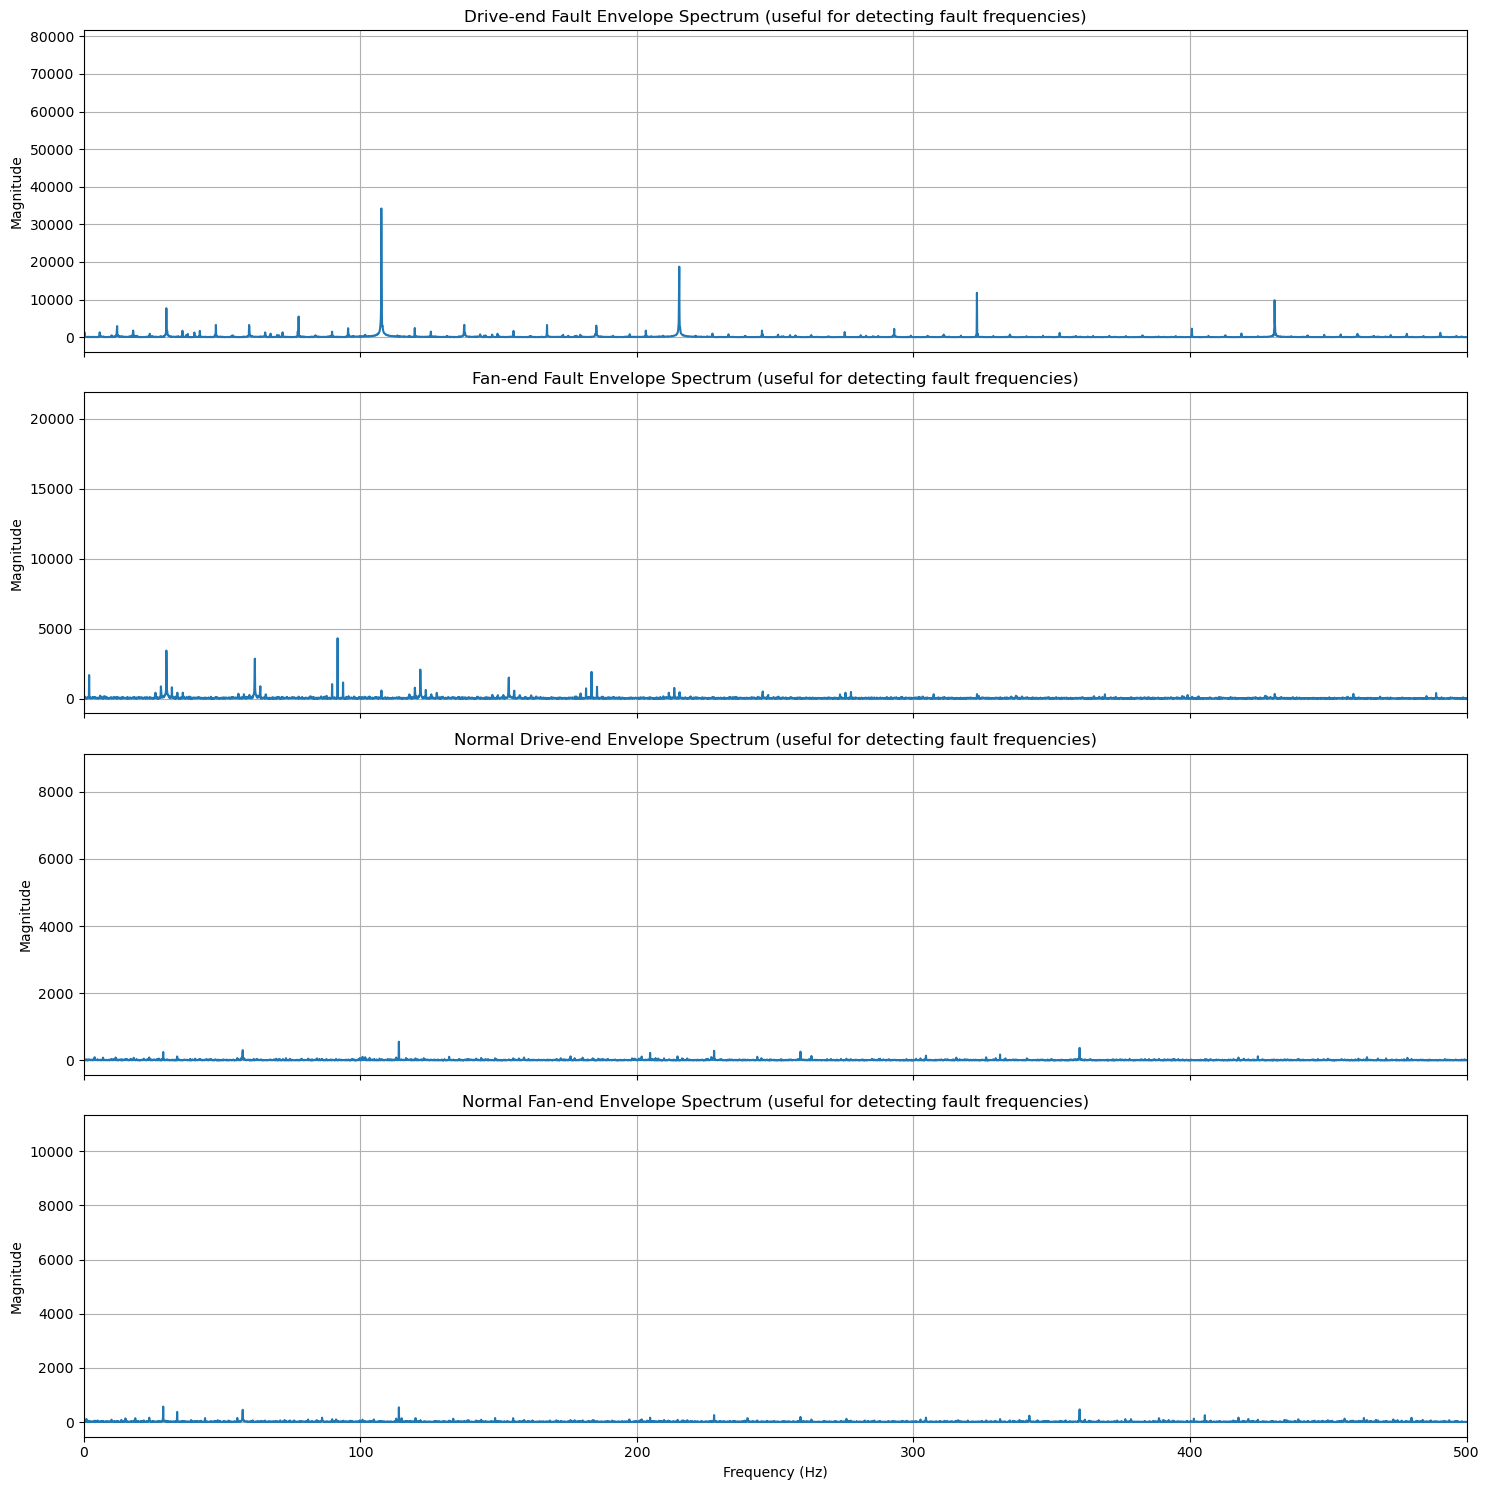

In [58]:
def fast_fourier_transform_envelope(fs, signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 15), sharex=True)
    for i in range(len(signal_list)):
        analytic_signal = hilbert(signal_list[i])
        amplitude_envelope = np.abs(analytic_signal)
        fft_envelope = np.fft.fft(amplitude_envelope)
        freq_envelope = np.fft.fftfreq(len(amplitude_envelope), 1/fs)

        axes[i].plot(freq_envelope[:len(freq_envelope)//2], 
            np.abs(fft_envelope[:len(fft_envelope)//2]))
        axes[i].set_ylabel('Magnitude')
        axes[i].set_title(f'{label_list[i]} Envelope Spectrum (useful for detecting fault frequencies)')
        axes[i].set_xlim(0, 500)
        axes[i].grid(True)

    axes[-1].set_xlabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()

fast_fourier_transform_envelope(12000, signal_list, label_list)

In [60]:
stats_df = pd.DataFrame(columns=['Label', 'Signal Power', 'Noise Estimate', 'Noise Power', 'Signal-to-Noise Ratio'])

for signal, label in zip(signal_list, label_list):
    signal_power = np.mean(signal**2)
    noise_estimate = np.std(signal)
    noise_power = noise_estimate**2
    snr = 10 * np.log10(signal_power / noise_power)
    stats = [
        label,
        signal_power,
        noise_estimate,
        noise_power,
        snr
    ]

    stats_df.loc[len(stats_df)] = stats

stats_df

,Label,Signal Power,Noise Estimate,Noise Power,Signal-to-Noise Ratio
0,Drive-end Fault,0.448238,0.669104,0.447701,0.005205
1,Fan-end Fault,0.023799,0.154251,0.023793,0.000990
2,Normal Drive-end,0.003355,0.056568,0.003200,0.205707
3,Normal Fan-end,0.005541,0.067259,0.004524,0.881001


# Histogram

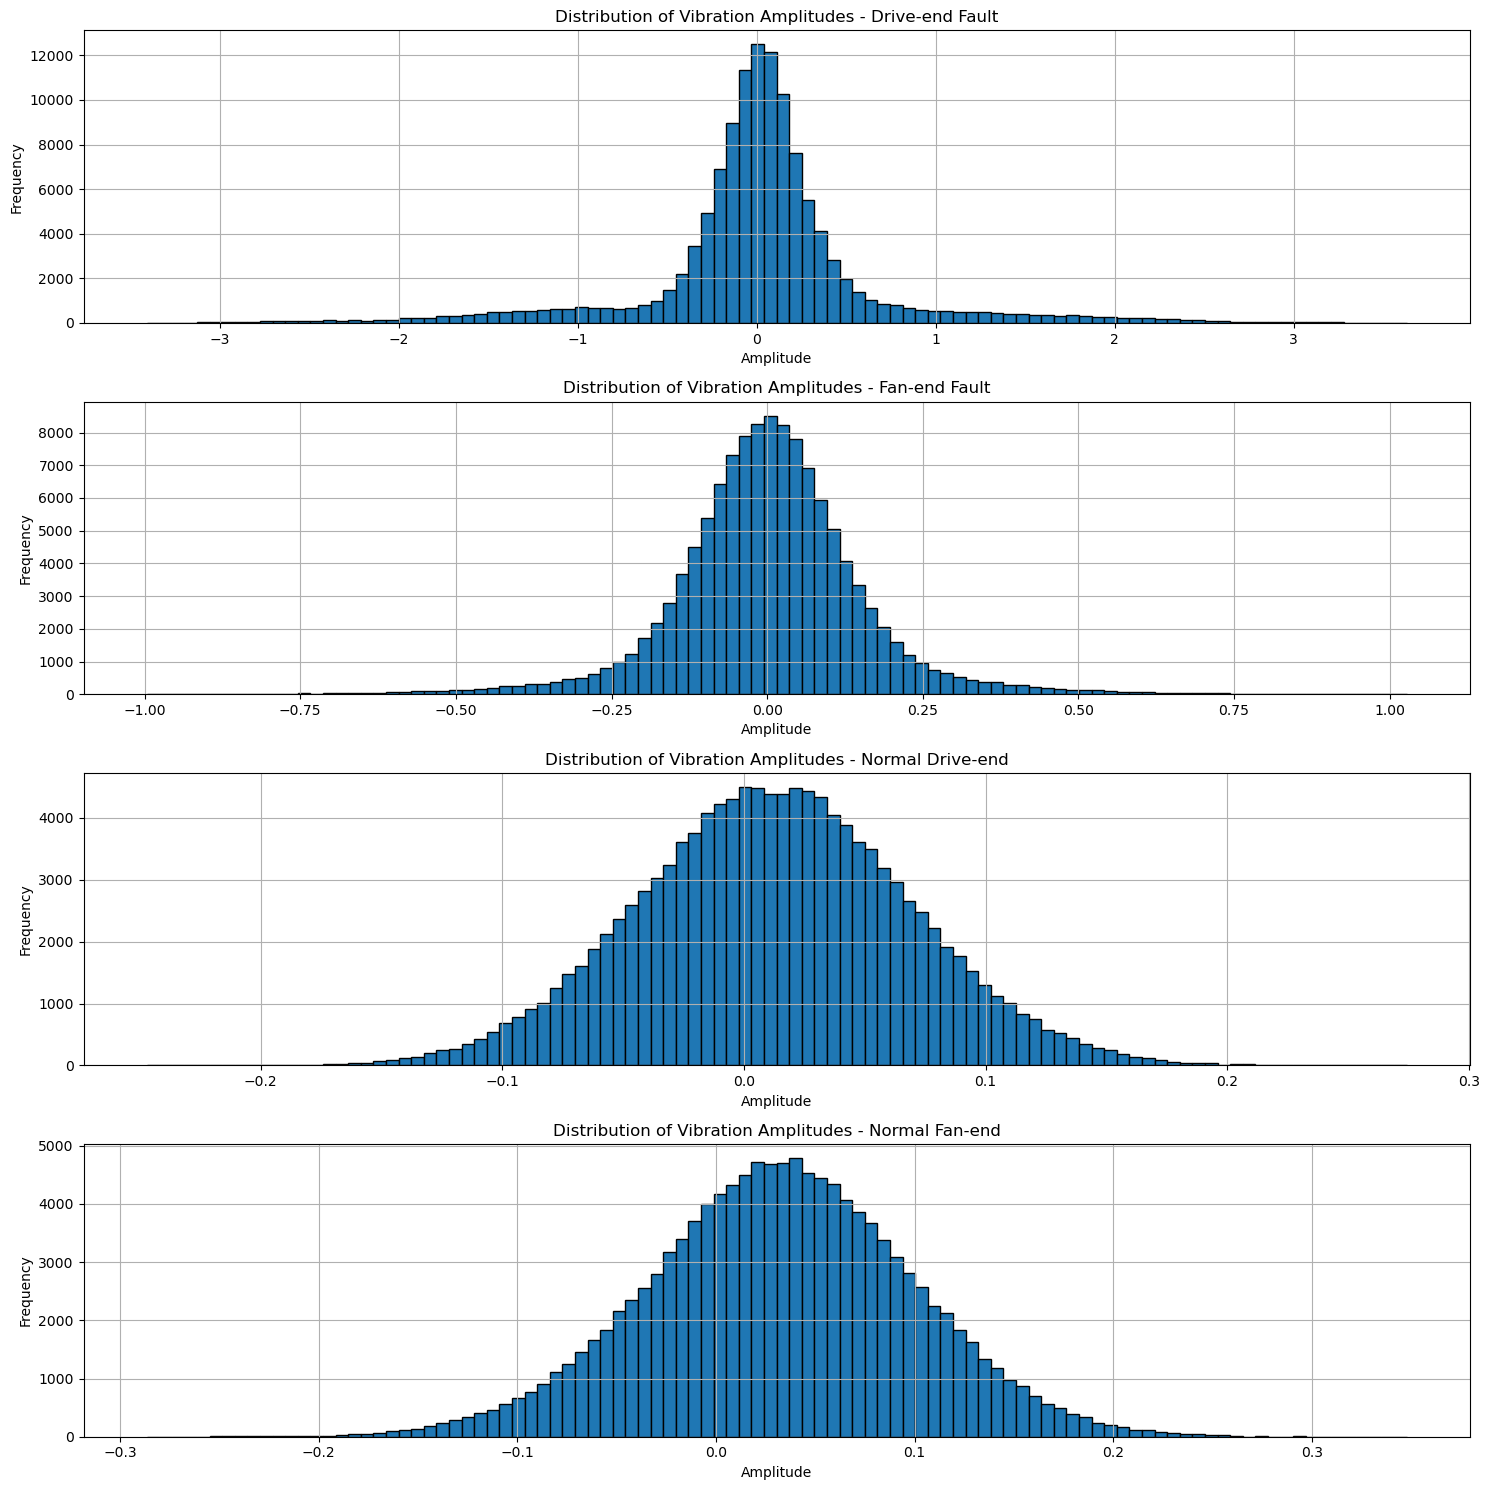

In [61]:
def histogram_signal(signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 15))
    for i in range(len(signal_list)):
        axes[i].hist(signal_list[i], bins=100, edgecolor='black')
        axes[i].set_xlabel('Amplitude')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Distribution of Vibration Amplitudes - {label_list[i]}')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

histogram_signal(signal_list, label_list)

# Q-Q plot

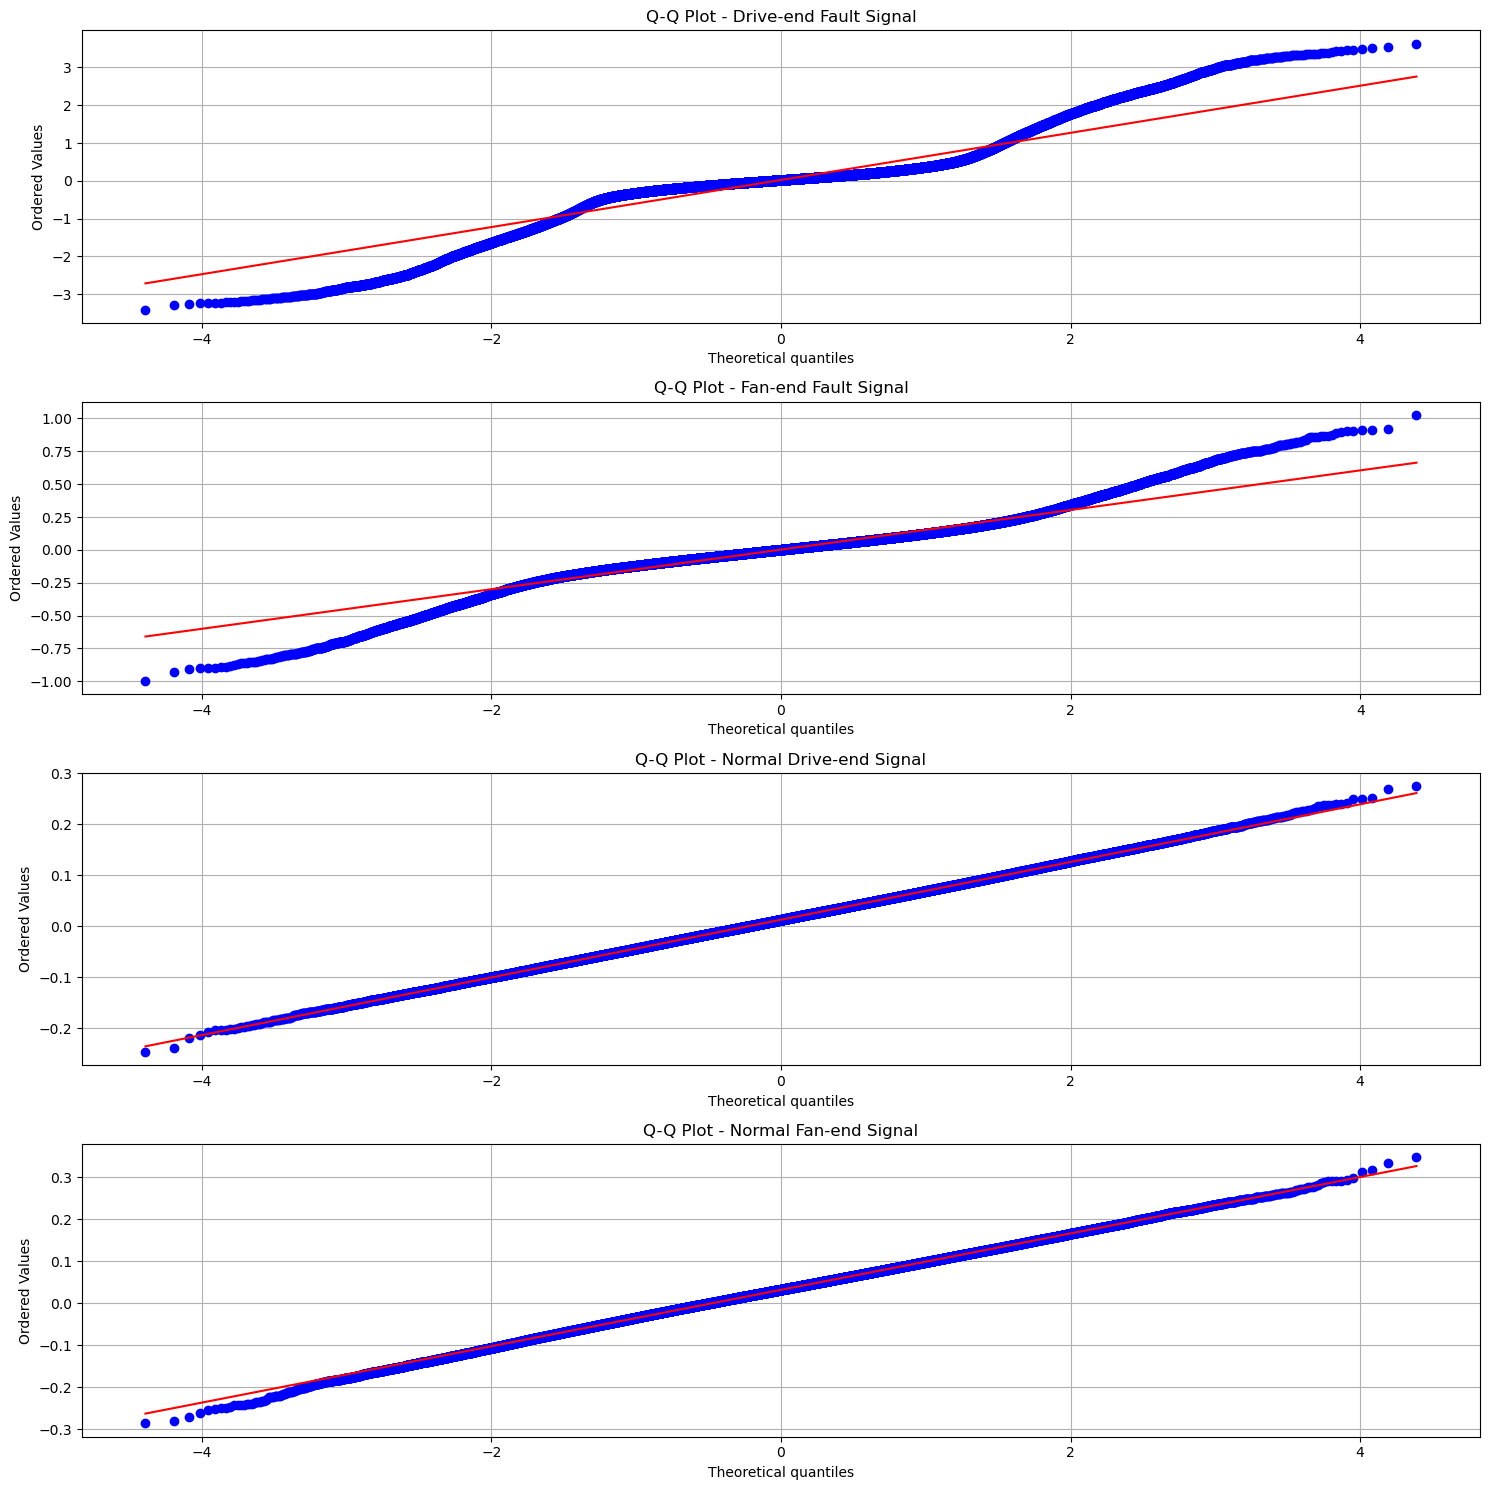

In [62]:
def qq_signal(signal_list, label_list):
    fig, axes = plt.subplots(len(signal_list), 1, figsize=(15, 15))
    for i in range(len(signal_list)):
        sps.probplot(signal_list[i], dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot - {label_list[i]} Signal')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

qq_signal(signal_list, label_list)  

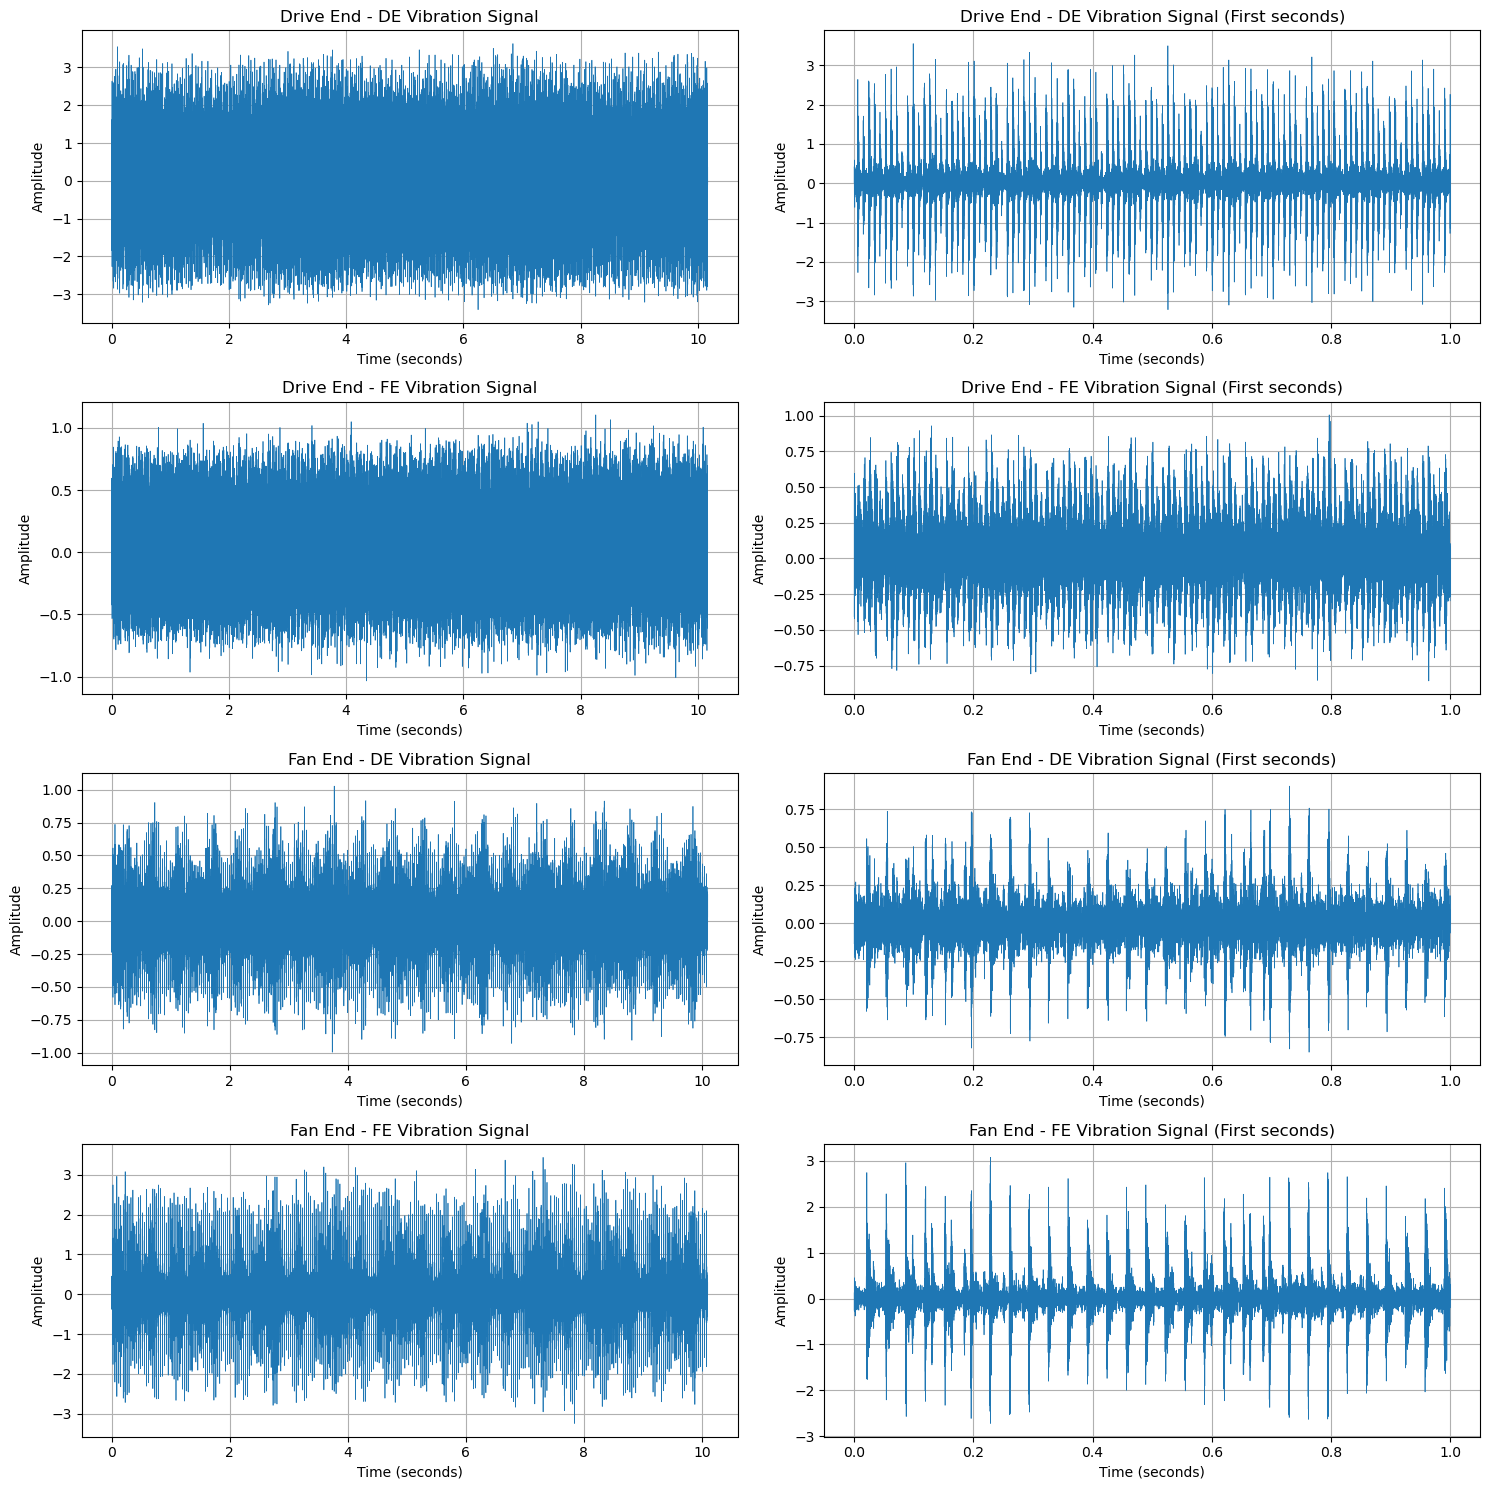

In [83]:
signal_list = [
    de_data['OR']['007']['@6'][0]['X130_DE_time'].squeeze(),
    de_data['OR']['007']['@6'][0]['X130_FE_time'].squeeze(),
    fe_data['OR']['007']['@6'][0]['X294_DE_time'].squeeze(),
    fe_data['OR']['007']['@6'][0]['X294_FE_time'].squeeze()
]

label_list = ["Drive End - DE", "Drive End - FE", "Fan End - DE", "Fan End - FE"]
        
raw_vibration_signal(12000, signal_list, label_list)

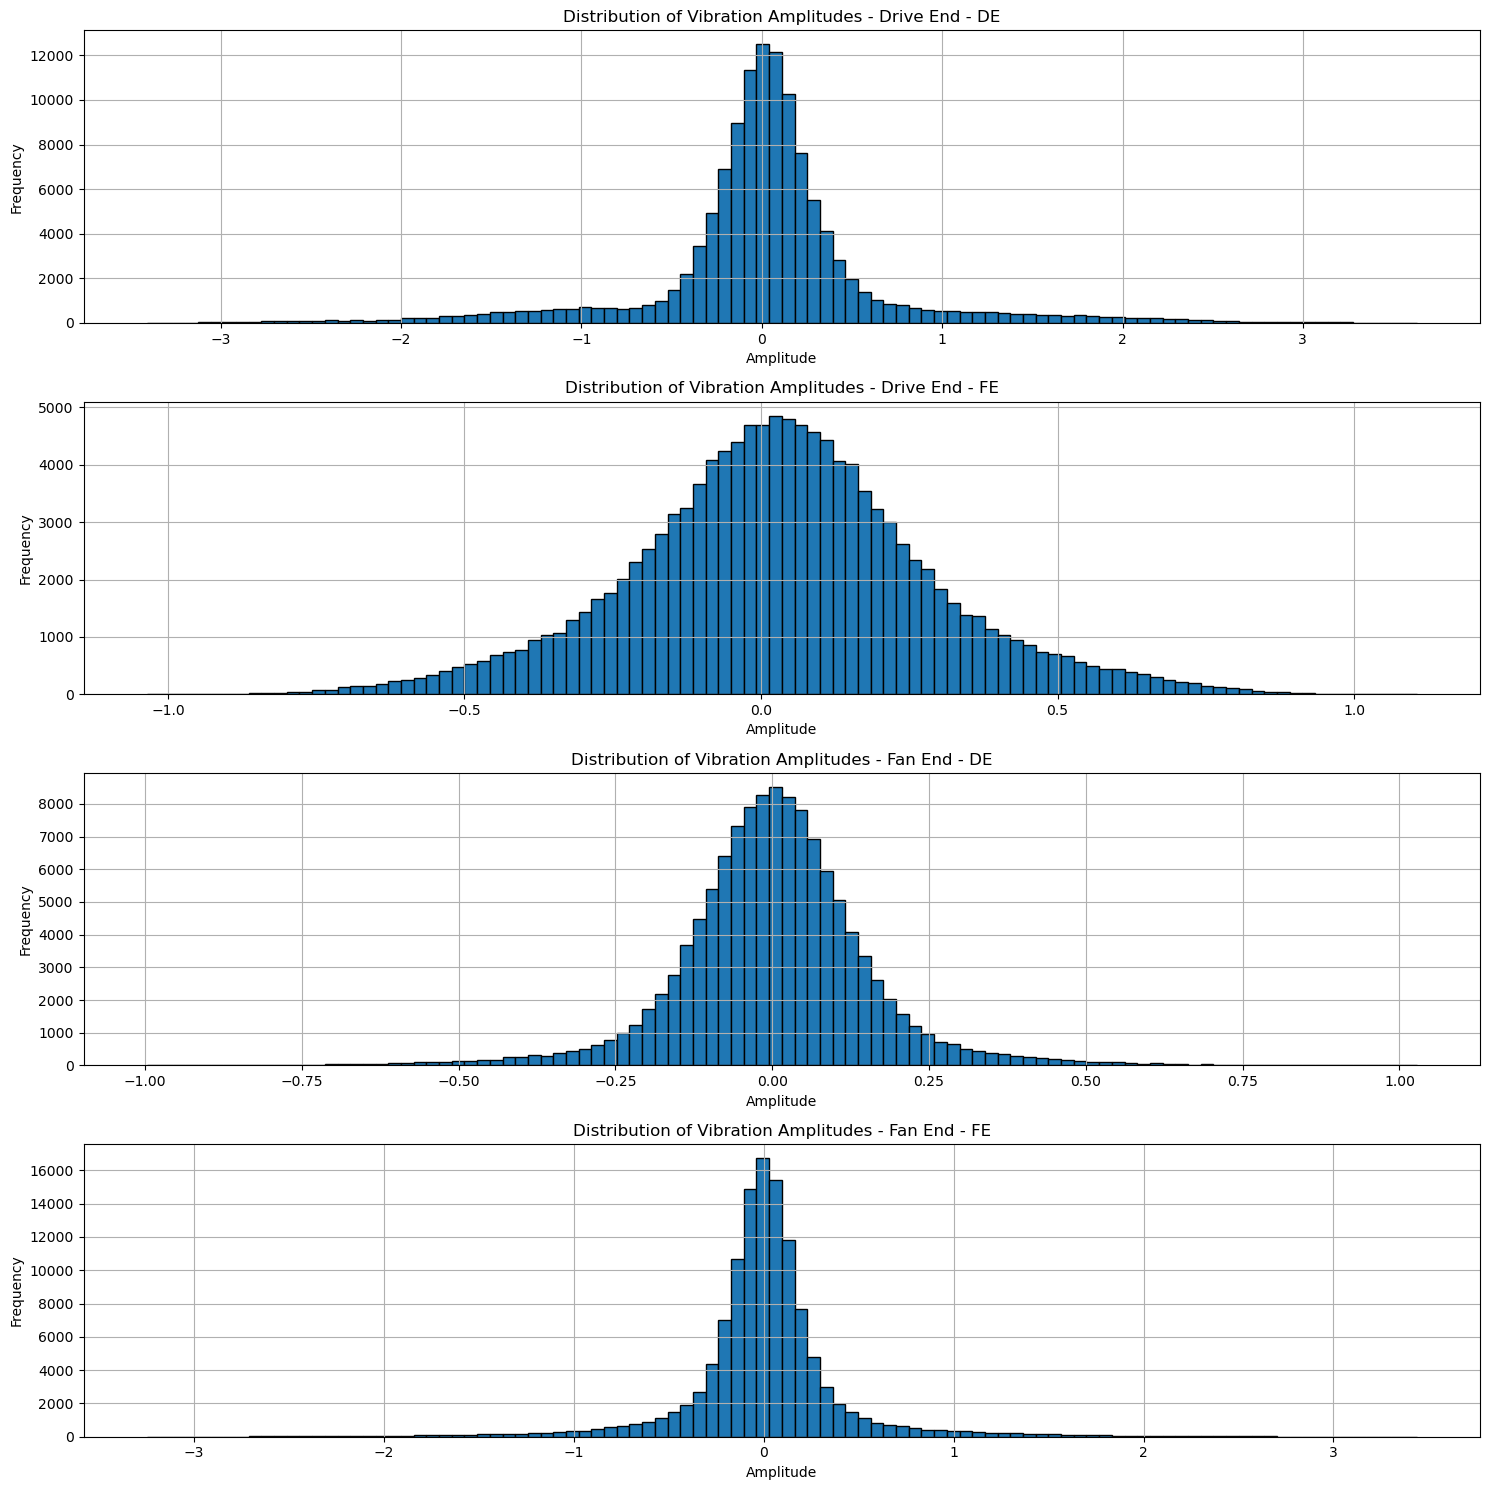

In [84]:
histogram_signal(signal_list, label_list)